In [86]:
import cf
import matplotlib.pyplot as plt
import cfplot as cfp
import jupyter_black

jupyter_black.load()
import numpy as np
import warnings
import glob
import os
import iris
import cartopy.crs as ccrs
import iris.quickplot as qplt

warnings.filterwarnings("ignore", module="iris.*")
import xarray as xr

In [81]:
cube1 = iris.load_cube(
    "/Users/sa931773@reading.ac.uk/nemo_dw696o_1d_18500101-18510101_grid-T.nc",
    "sea_surface_temperature",
)

cube2 = iris.load_cube(
    "/Users/sa931773@reading.ac.uk/nemo_dw704o_1d_18500101-18510101_grid-T.nc",
    "sea_surface_temperature",
)

new_cube1, extent = iris.analysis.cartography.project(
    cube1, ccrs.PlateCarree(), nx=400, ny=200
)

new_cube2, extent = iris.analysis.cartography.project(
    cube2, ccrs.PlateCarree(), nx=400, ny=200
)

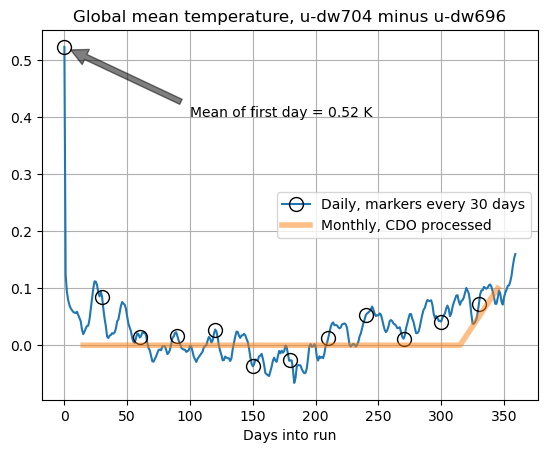

In [146]:
fig, ax = plt.subplots()

ax.plot(
    np.arange(cube1.shape[0]),
    (new_cube2 - new_cube1)
    .collapsed(["latitude", "longitude"], iris.analysis.MEAN)
    .data,
    "-",
    marker="o",
    markevery=30,
    markeredgecolor="k",
    markersize=10,
    fillstyle="none",
    label="Daily, markers every 30 days",
)

ax.annotate(
    f"Mean of first day = {(new_cube2 - new_cube1).collapsed(['latitude', 'longitude'], 
                                                             iris.analysis.MEAN).data[0]:.2f} K",
    xy=(
        np.arange(cube1.shape[0])[0],
        (new_cube2 - new_cube1)
        .collapsed(["latitude", "longitude"], iris.analysis.MEAN)
        .data[0],
    ),  # Where the arrow points (x, y coordinates)
    xytext=(100, 0.4),  # Where the text is placed
    arrowprops=dict(facecolor="black", shrink=0.05, alpha=0.5),  # Adds the arrow
)


files1 = sorted(glob.glob("/Users/sa931773@reading.ac.uk/nemo_dw696o_1m*.nc"))
files2 = sorted(glob.glob("/Users/sa931773@reading.ac.uk/nemo_dw704o_1m*.nc"))

prefix = "new_"
# prefix = ""

arr = [
    iris.load_cube(
        files2[i].replace("nemo", prefix + "nemo"), "sea_surface_temperature"
    )
    .collapsed(["latitude", "longitude"], iris.analysis.MEAN)
    .data.item()
    - iris.load_cube(
        files1[i].replace("nemo", prefix + "nemo"), "sea_surface_temperature"
    )
    .collapsed(["latitude", "longitude"], iris.analysis.MEAN)
    .data.item()
    for i in range(12)
]

plt.plot(
    np.linspace(30, 360, 12) - 15,
    arr,
    linewidth=4,
    alpha=0.5,
    label="Monthly" + (", CDO processed") * (prefix == "new_"),
)

plt.xlabel("Days into run")
plt.title("Global mean temperature, u-dw704 minus u-dw696")
plt.grid()
plt.legend()
plt.show();

In [138]:
files1[0].replace("nemo", "new_nemo")

'/Users/sa931773@reading.ac.uk/new_nemo_dw696o_1m_18500101-18500201_grid-T.nc'